### **Mount to the Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2'

%cd $base_dir

Mounted at /content/drive
/content/drive/MyDrive/epipolar-geometry-dinov2/epipolar-geometry-dinov2


In [2]:
# Run the command below if you need
!pip install -q -r requirements.txt

In [55]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [56]:
left_img_path = f'{base_dir}/data/kitti_sample/sequences/00/image_2/000000.png'
right_img_path = f'{base_dir}/data/kitti_sample/sequences/00/image_3/000000.png'

left_img = cv.imread(left_img_path, cv.IMREAD_GRAYSCALE)
right_img = cv.imread(right_img_path, cv.IMREAD_GRAYSCALE)

In [190]:
window_size = 3
min_disp = 0
num_disp = 128

In [191]:
stereo = cv.StereoSGBM_create(minDisparity = min_disp,
        numDisparities = num_disp,
        blockSize = 7,
        P1 = 8*3*window_size**2,
        P2 = 32*3*window_size**2,
        disp12MaxDiff = 1,
        uniquenessRatio = 10,
        speckleWindowSize = 100,
        speckleRange = 2,
        mode = cv.STEREO_SGBM_MODE_SGBM_3WAY
)

disparity_SGBM = stereo.compute(left_img, right_img)

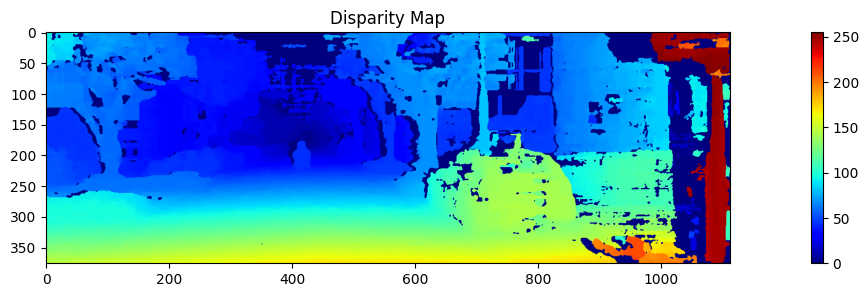

In [193]:
disparity_SGBM = disparity_SGBM.astype(np.float32) / 16.0
disparity_SGBM = cv.normalize(disparity_SGBM, disparity_SGBM, alpha=255,
                              beta=0, norm_type=cv.NORM_MINMAX)
disparity_SGBM = np.uint8(disparity_SGBM)
disparity_cropped = disparity_SGBM[:, num_disp:]

plt.figure(figsize=(21,3))
plt.title("Disparity Map")
plt.imshow(disparity_cropped, cmap='jet')
plt.colorbar()
plt.show()